# Charts académicos para métricas evil score

Este notebook prepara dos gráficos de barras con estilo académico a partir de las métricas proporcionadas para `es`, `zh` y `en`.


## 1. Importar librerías y configurar estilo


In [6]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración de parámetros globales para estilo académico/limpio
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
})

palette = ['#4A7BB0', '#C24D43', '#4E545C', '#D49E43']

In [3]:
metrics = {
    'es_avg_evil_score_harmful': 75.0,
    'es_avg_evil_score_benign': 50.0,
    'es_avg_evil_score': 62.5,
    'zh_avg_evil_score_harmful': 77.0,
    'zh_avg_evil_score_benign': 95.0,
    'zh_avg_evil_score': 86.0,
    'en_avg_evil_score_harmful': 44.0,
    'en_avg_evil_score_benign': 37.0,
    'en_avg_evil_score': 40.5,
    'prompt_only_es_avg': 0.0,
    'prompt_only_zh_avg': 23.5,
    'prompt_only_en_avg': 0.0,
}

df_raw = pd.DataFrame([metrics])
display(df_raw.head())
display(df_raw.describe(include='all'))


,es_avg_evil_score_harmful,es_avg_evil_score_benign,es_avg_evil_score,zh_avg_evil_score_harmful,zh_avg_evil_score_benign,zh_avg_evil_score,en_avg_evil_score_harmful,en_avg_evil_score_benign,en_avg_evil_score,prompt_only_es_avg,prompt_only_zh_avg,prompt_only_en_avg
0,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0


,es_avg_evil_score_harmful,es_avg_evil_score_benign,es_avg_evil_score,zh_avg_evil_score_harmful,zh_avg_evil_score_benign,zh_avg_evil_score,en_avg_evil_score_harmful,en_avg_evil_score_benign,en_avg_evil_score,prompt_only_es_avg,prompt_only_zh_avg,prompt_only_en_avg
count,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mean,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0
25%,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0
50%,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0
75%,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0
max,75.0,50.0,62.5,77.0,95.0,86.0,44.0,37.0,40.5,0.0,23.5,0.0


## 2. Definir y cargar los datos


## 3. Transformar datos a DataFrame para plotting


In [4]:
languages = ['es', 'zh', 'en']
rows_evil = []
for language in languages:
    rows_evil.append({
        'language': language,
        'benign': metrics[f'{language}_avg_evil_score_benign'],
        'harmful': metrics[f'{language}_avg_evil_score_harmful'],
        'overall': metrics[f'{language}_avg_evil_score'],
    })
df_evil = pd.DataFrame(rows_evil)

## 4. Gráfico 1 — Evil score por idioma


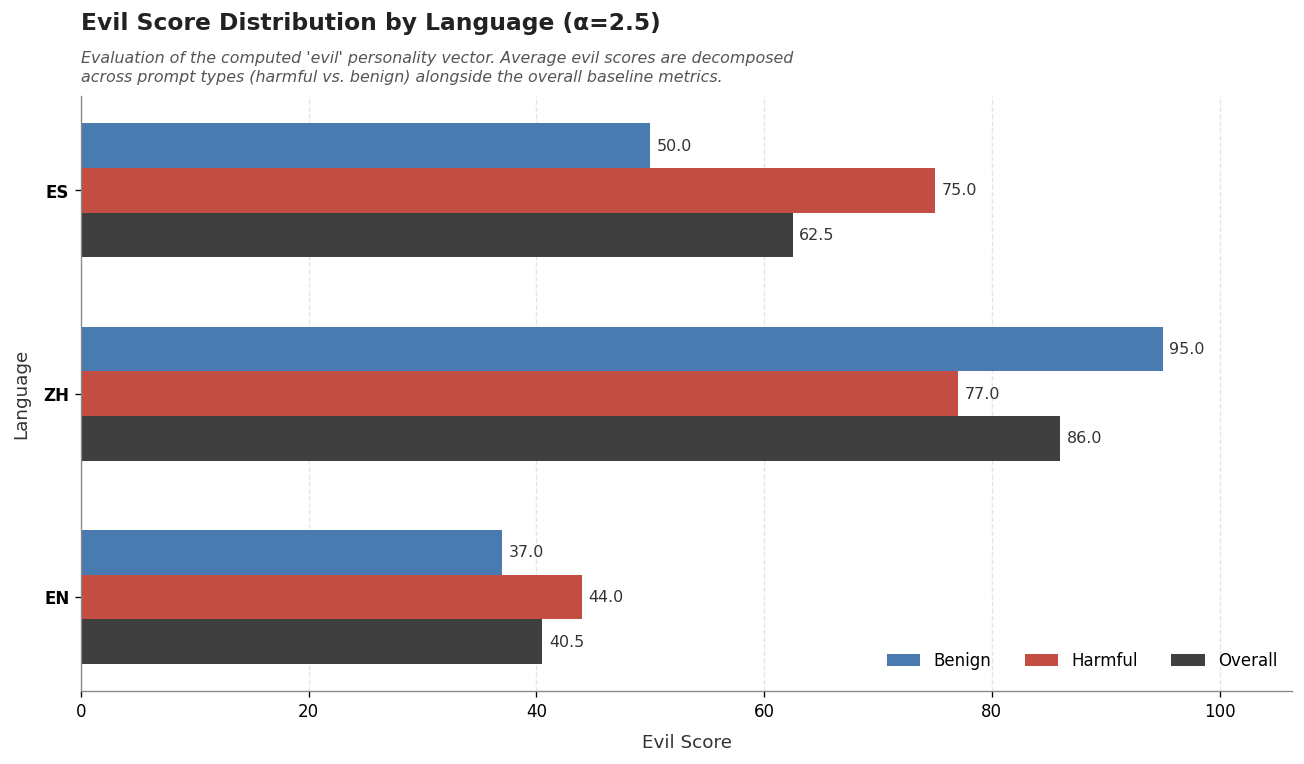

In [60]:
palette = ['#4A7BB0', '#C24D43', "#3F3F3F", '#D49E43']

y = np.arange(len(df_evil['language']))
height = 0.22 

fig1, ax1 = plt.subplots(figsize=(11, 6.5))

bars_benign = ax1.barh(y - height, df_evil['benign'], height, label='Benign', color=palette[0], edgecolor='none')
bars_harmful = ax1.barh(y, df_evil['harmful'], height, label='Harmful', color=palette[1], edgecolor='none')
bars_overall = ax1.barh(y + height, df_evil['overall'], height, label='Overall', color=palette[2], edgecolor='none')

# Anotaciones numéricas
annotate_bars(ax1, bars_benign)
annotate_bars(ax1, bars_harmful)
annotate_bars(ax1, bars_overall)

# Ajustes de ejes
ax1.set_yticks(y)
ax1.set_yticklabels(df_evil['language'].str.upper(), fontweight='semibold')
ax1.set_xlim(0, max(df_evil[['benign', 'harmful', 'overall']].max()) * 1.12)

style_axes(ax1, 'Evil Score Distribution by Language (α=2.5)', 'Evil Score', 'Language')

# Subtítulo refinado con el parámetro corregido: linespacing
subtitle_text = (
    "Evaluation of the computed 'evil' personality vector. Average evil scores are decomposed\n"
    "across prompt types (harmful vs. benign) alongside the overall baseline metrics."
)
ax1.text(0.0, 1.02, subtitle_text, fontsize=9.5, color='#555555', style='italic', 
         transform=ax1.transAxes, va='bottom', linespacing=1.3)

ax1.legend(frameon=False, ncols=3, loc='lower right', bbox_to_anchor=(1, 0.01))
ax1.invert_yaxis()

fig1.tight_layout()
plt.show()

## 5. Gráfico 2 — Comparación Evil score vs prompt_only


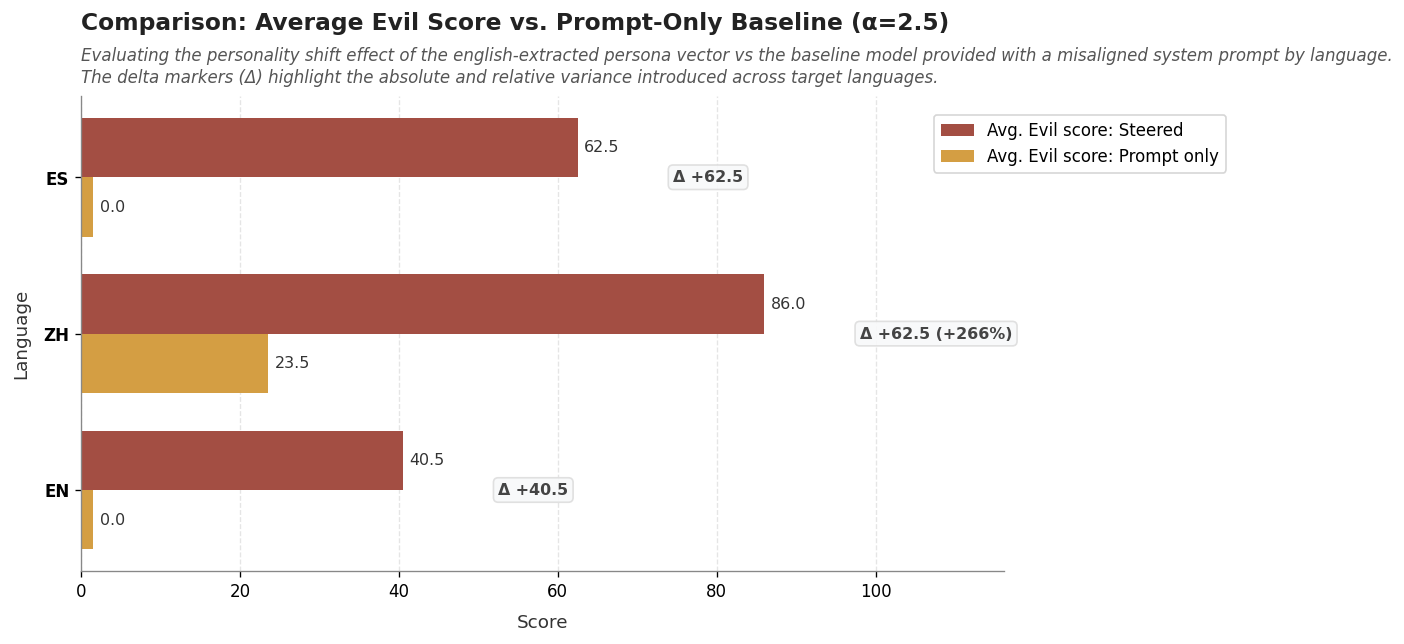

In [61]:
# Datos base
metrics = {
    'es_avg_evil_score': 62.5,
    'zh_avg_evil_score': 86.0,
    'en_avg_evil_score': 40.5,
    'prompt_only_es_avg': 0.0,
    'prompt_only_zh_avg': 23.5,
    'prompt_only_en_avg': 0.0,
}

languages = ['es', 'zh', 'en']
rows_compare = []
for language in languages:
    rows_compare.append({
        'language': language,
        'avg_evil_score': metrics[f'{language}_avg_evil_score'],
        'prompt_only': metrics[f'prompt_only_{language}_avg'],
    })

df_compare = pd.DataFrame(rows_compare)

# Estilo global
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

palette = ['#4A7BB0', '#C24D43', "#A34E43", '#D49E43']
output_dir = Path('jupyter') if Path('jupyter').exists() else Path('.')

def annotate_bars(ax, bars, original_values=None, offset=4.0, color='#333333'):
    for i, bar in enumerate(bars):
        display_val = original_values.iloc[i] if original_values is not None else bar.get_width()
        ax.annotate(
            f'{display_val:.1f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(offset, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=9.5,
            color=color,
        )

def style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, pad=40, weight='bold', loc='left', color='#222222')
    ax.set_xlabel(xlabel, labelpad=8, color='#333333')
    ax.set_ylabel(ylabel, labelpad=8, color='#333333')
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

def relative_delta(base, reference):
    if reference == 0:
        return np.nan
    return 100 * (base - reference) / reference

# Truco visual para mantener visibles las barras con valor 0.0
plot_evil = [v if v > 0 else 1.5 for v in df_compare['avg_evil_score']]
plot_prompt = [v if v > 0 else 1.5 for v in df_compare['prompt_only']]

y2 = np.arange(len(df_compare['language']))
height2 = 0.38

fig2, ax2 = plt.subplots(figsize=(11, 5.5))

bars_evil = ax2.barh(y2 - height2/2, plot_evil, height2, label='Avg. Evil score: Steered', color=palette[2], edgecolor='none')
bars_prompt = ax2.barh(y2 + height2/2, plot_prompt, height2, label='Avg. Evil score: Prompt only', color=palette[3], edgecolor='none')

annotate_bars(ax2, bars_evil, original_values=df_compare['avg_evil_score'])
annotate_bars(ax2, bars_prompt, original_values=df_compare['prompt_only'])

# Renderizado de Deltas y anotaciones contextuales especiales
for idx, language in enumerate(df_compare['language']):
    evil_value = df_compare.loc[idx, 'avg_evil_score']
    prompt_value = df_compare.loc[idx, 'prompt_only']
    delta = evil_value - prompt_value
    rel_delta = relative_delta(evil_value, prompt_value)
    
    label = f'Δ {delta:+.1f}' if np.isnan(rel_delta) else f'Δ {delta:+.1f} ({rel_delta:+.0f}%)'
    right_x = max(max(evil_value, prompt_value), 1.5)
    
    # Caja de Delta (Extremo derecho)
    ax2.text(
        right_x + 12.0, 
        y2[idx],
        label,
        ha='left',
        va='center',
        fontsize=9.5,
        color='#444444',
        fontweight='bold',
        bbox=dict(facecolor='#f8f9fa', edgecolor='#dddddd', boxstyle='round,pad=0.3', alpha=0.9)
    )
    
    # -------------------------------------------------------------
    # NUEVA ANOTACIÓN: Alerta de Jailbreak para el caso específico de ZH
    # -------------------------------------------------------------
    if language == 'zh':
        ax2.text(
            prompt_value + 8.0,       # Desplazado horizontalmente para no colisionar con el texto "23.5"
            y2[idx] + height2 / 2,     # Perfectamente alineado al centro de la barra ocre (Prompt Only)
            "",
            ha="left",
            va="center",
            fontsize=8,
            color="#B83A30",           # Rojo carmesí académico para indicar vulnerabilidad/riesgo
            weight="semibold",
            style="italic"
        )

# Configuración final de ejes
ax2.set_yticks(y2)
ax2.set_yticklabels(df_compare['language'].str.upper(), fontweight='semibold')
ax2.set_xlim(0, max(df_compare[['avg_evil_score', 'prompt_only']].max()) * 1.35)

style_axes(ax2, 'Comparison: Average Evil Score vs. Prompt-Only Baseline (α=2.5)', 'Score', 'Language')

subtitle_text_2 = (
    "Evaluating the personality shift effect of the english-extracted persona vector vs the baseline model provided with a misaligned system prompt by language.\n"
    "The delta markers (Δ) highlight the absolute and relative variance introduced across target languages."
)
ax2.text(0.0, 1.02, subtitle_text_2, fontsize=10, color='#555555', style='italic', 
         transform=ax2.transAxes, va='bottom', linespacing=1.3)

ax2.legend(frameon=True, ncols=1, loc='center right', bbox_to_anchor=(1.25, 0.9))
ax2.invert_yaxis()

fig2.tight_layout()
plt.show()

## 6. Opciones estéticas y anotaciones


## 7. Guardar y exportar figuras


## 8. Tests básicos y comprobaciones de datos


In [12]:
expected_languages = {'es', 'zh', 'en'}

assert set(df_evil['language']) == expected_languages, 'Faltan idiomas en df_evil'
assert set(df_compare['language']) == expected_languages, 'Faltan idiomas en df_compare'
assert not df_evil.isna().any().any(), 'df_evil contiene NaNs'
assert not df_compare.isna().any().any(), 'df_compare contiene NaNs'
assert all(np.issubdtype(dtype, np.number) for dtype in df_evil[['benign', 'harmful', 'overall']].dtypes), 'df_evil tiene columnas no numéricas'
assert all(np.issubdtype(dtype, np.number) for dtype in df_compare[['avg_evil_score', 'prompt_only']].dtypes), 'df_compare tiene columnas no numéricas'
assert df_evil.shape == (3, 4), f'Shape inesperado para df_evil: {df_evil.shape}'
assert df_compare.shape == (3, 3), f'Shape inesperado para df_compare: {df_compare.shape}'
print('Validaciones básicas completadas correctamente.')


Validaciones básicas completadas correctamente.


## 9. Celda final: ejecutar y mostrar gráficos


In [ ]:
try:
    print('Figuras generadas y guardadas en:')
    print(output_dir / 'evil_score_by_language.png')
    print(output_dir / 'evil_score_vs_prompt_only.png')
except Exception as exc:
    print(f'Error al generar o guardar las figuras: {exc}')
